In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
ds = xr.open_dataset('../../ff1/rest/0001-01-06-00000/ff1.cam.h1.0001-01-01-00000.nc')

In [4]:
ds

<xarray.Dataset> Size: 149MB
Dimensions:       (lat: 192, lon: 288, lev: 32, ilev: 33, time: 21, nbnd: 2)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 168B 0001-01-01 00:00:00 ... 0001-01-06 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (lat) float64 2kB ...
    hyam          (lev) float64 256B ...
    hybm          (lev) float64 256B ...
    P0            float64 8B ...
    hyai          (ilev) float64 264B ...
    hybi          (ilev) float64 264B ...
    ...            ...
    n2ovmr        (time) float64 168B ...
    f11vmr        (time) float64 168B ...
    f12vmr        (time) float64 168B ...
    sol_tsi       (time) float64 168B ...
    nsteph        (time) int32 84B ...
    T             (time, lev, lat, lon) float32 149MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              ff1
    logname:           ags
    host:              
    initial_file:      /scratch/tresa/cesm_input_datasets/atm/cam/inic/fv/cam...
    topography_file:   /scratch/tresa/cesm_input_datasets/atm/cam/topo/fv_0.9...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6

/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/matplotlib/colors.py:1404: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin
/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/matplotlib/colors.py:1404: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/matplotlib/colors.py:1404: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin
/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/matplotlib/colors.py:1404: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


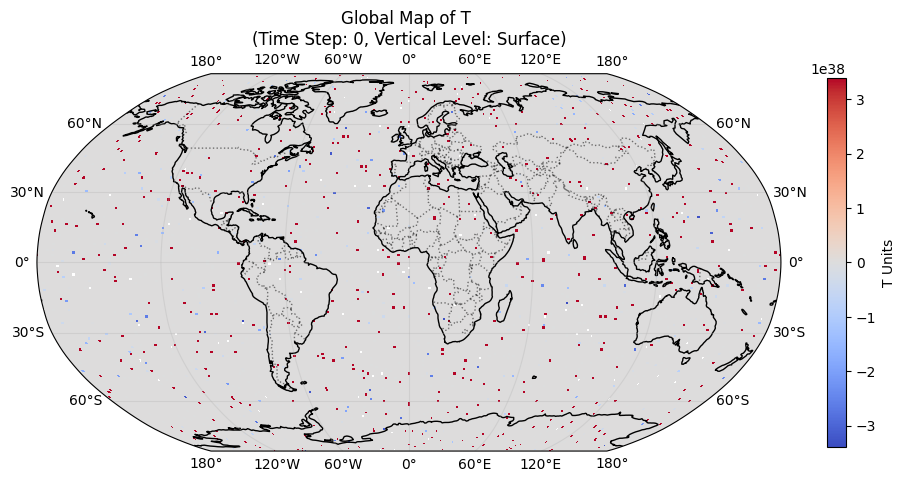

In [5]:
# 1. Select the specific variable you want to plot (e.g., Temperature, Wind)
# Replace 'VAR_NAME' with the actual variable in your dataset
var_name = 'T' 

# 2. Slice the data to 2D (lat, lon)
# Here we select the first time step (index 0) and the surface level (often the last index, -1, in models)
data_to_plot = ds[var_name].isel(time=0, lev=-1)

# 3. Set up the figure and the map projection
# PlateCarree is a standard equirectangular projection, but Robinson is also great for global maps
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

# 4. Add geographic features for context
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)

# 5. Plot the data using xarray's built-in plotting function
# We must specify transform=ccrs.PlateCarree() because the raw data is in lat/lon coordinates
plot = data_to_plot.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='coolwarm',
    #vmin=220,  # Minimum temperature to show (e.g., 220 K)
    #vmax=320,  # Maximum temperature to show (e.g., 320 K)
    cbar_kwargs={'shrink': 0.8, 'label': f'{var_name} Units'}
)

# 6. Add a descriptive title
plt.title(f'Global Map of {var_name} \n(Time Step: 0, Vertical Level: Surface)')

plt.show()

In [6]:
ds.mean('lat')
ds.mean('lon')

/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ags/.pyenv/versions/3.9.19/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


<xarray.Dataset> Size: 523kB
Dimensions:       (lat: 192, lev: 32, ilev: 33, time: 21, nbnd: 2)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 168B 0001-01-01 00:00:00 ... 0001-01-06 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (lat) float64 2kB 3.382e-05 0.0002705 ... 0.0002705 3.382e-05
    hyam          (lev) float64 256B 0.003643 0.007595 0.01436 ... 0.001989 0.0
    hybm          (lev) float64 256B 0.0 0.0 0.0 0.0 ... 0.9512 0.9743 0.9926
    P0            float64 8B 1e+05
    hyai          (ilev) float64 264B 0.002255 0.005032 0.01016 ... 0.0 0.0
    hybi          (ilev) float64 264B 0.0 0.0 0.0 0.0 ... 0.9636 0.9851 1.0
    ...            ...
    n2ovmr        (time) float64 168B 3.156e-07 3.156e-07 ... 3.155e-07
    f11vmr        (time) float64 168B 6.929e-10 6.928e-10 ... 6.921e-10
    f12vmr        (time) float64 168B 5.39e-10 5.39e-10 ... 5.387e-10 5.387e-10
    sol_tsi       (time) float64 168B -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    nsteph        (time) int32 84B 0 12 24 36 48 60 ... 180 192 204 216 228 240
    T             (time, lev, lat) float32 516kB 32.56 32.56 ... -3.086e+13